In [1]:
import sqlite3
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## Connect to SQL Database

I've now added in the new tables containig the user's playlists and tracks.

In [2]:
# Connect to SQLite database
conn = sqlite3.connect("spotify_dataset.db")
cursor = conn.cursor()

# List all tables in the database
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

# Fetch and print table names
tables = cursor.fetchall()
print("Tables in database:", tables)

Tables in database: [('spotify_tracks',), ('user_playlists',), ('user_tracks',)]


In [3]:
# Load dataset from SQLite
with sqlite3.connect("spotify_dataset.db") as conn:
    df_spotify_tracks = pd.read_sql_query("SELECT * FROM spotify_tracks;", conn)
    df_user_playlists = pd.read_sql_query("SELECT * FROM user_playlists;", conn)
    df_user_tracks = pd.read_sql_query("SELECT * FROM user_tracks;", conn)

In [4]:
"""Use left join in SQL to combine user_tracks and user_playlists."""

cmd = """SELECT P.id, P.name, P.owner_id, P.owner_display_name, T.playlist_id, T.track_id, T.track_explicit, T.track_album_id, T.track_artists, T.track_duration_ms, T.track_href, T.track_name, T.track_popularity
FROM user_tracks T 
LEFT JOIN user_playlists P 
ON T.playlist_id = P.id"""

with sqlite3.connect("spotify_dataset.db") as conn:
    df_users_PandT = pd.read_sql_query(cmd, conn)
df_users_PandT.head()

,id,name,owner_id,owner_display_name,playlist_id,track_id,track_explicit,track_album_id,track_artists,track_duration_ms,track_href,track_name,track_popularity
0,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,0yOf4dgkVq8jbB2zxVK8Zj,0.0,02zGqoK00H1Rx5T5A9dUXI,"[{""external_urls"": {""spotify"": ""https://open.s...",178000.0,https://api.spotify.com/v1/tracks/0yOf4dgkVq8j...,August 10,80.0
1,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,4qCV8C8UNSY6acKaq9Q9A0,0.0,02zGqoK00H1Rx5T5A9dUXI,"[{""external_urls"": {""spotify"": ""https://open.s...",114000.0,https://api.spotify.com/v1/tracks/4qCV8C8UNSY6...,Sorry Story,33.0
2,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,4NUhcsz9E1LrBe8nXLZqzp,0.0,4p3eRdoK7W7z0tz8OWA3JM,"[{""external_urls"": {""spotify"": ""https://open.s...",152000.0,https://api.spotify.com/v1/tracks/4NUhcsz9E1Lr...,It Almost Worked,76.0
3,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,37l31PrCNsg8baUjarNAi9,0.0,0YjOnBY0FRufcmNBTzWTgX,"[{""external_urls"": {""spotify"": ""https://open.s...",198213.0,https://api.spotify.com/v1/tracks/37l31PrCNsg8...,I Can't Handle Change,78.0
4,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,3UGaLiDr0puYtIAhkDCD2J,0.0,2PWdXoJgmQC9VAQmLQLi1Q,"[{""external_urls"": {""spotify"": ""https://open.s...",96853.0,https://api.spotify.com/v1/tracks/3UGaLiDr0puY...,drain you,58.0


In [5]:
df_spotify_tracks.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [6]:
df_user_playlists.head()

,id,href,description,name,owner_id,owner_display_name,tracks_href,username
0,6csfOWUiqHqZCbKi7oiqu9,https://api.spotify.com/v1/playlists/6csfOWUiq...,Playlist of similar songs based on August 10 b...,August 10,skeletongurlgame,Ava.jts,https://api.spotify.com/v1/playlists/6csfOWUiq...,Ava.jts
1,1rHNyjILyZMYPqtUBrK6aa,https://api.spotify.com/v1/playlists/1rHNyjILy...,,Another Indie Playlist,skeletongurlgame,Ava.jts,https://api.spotify.com/v1/playlists/1rHNyjILy...,Ava.jts
2,4VrgDdNjljYe5f9ftLooXd,https://api.spotify.com/v1/playlists/4VrgDdNjl...,Playlist of similar songs based on Inside Out ...,Sad Sad Sad,skeletongurlgame,Ava.jts,https://api.spotify.com/v1/playlists/4VrgDdNjl...,Ava.jts
3,1yI15ngEZ2Yb5OKY409sQ3,https://api.spotify.com/v1/playlists/1yI15ngEZ...,This playlist was created by https:&#x2F;&#x2F...,Need a beat and some sad lyrics,skeletongurlgame,Ava.jts,https://api.spotify.com/v1/playlists/1yI15ngEZ...,Ava.jts
4,0qANIO5qxX93MV2ZfAS30h,https://api.spotify.com/v1/playlists/0qANIO5qx...,Please add the top five songs from your 2024 S...,W25 NSDC Team Playlist!,315qy5gce4c4gy2gl4u27w2ru5wm,Izzy,https://api.spotify.com/v1/playlists/0qANIO5qx...,Ava.jts


In [7]:
df_user_tracks.head()

,playlist_id,track_id,track_explicit,track_album_id,track_artists,track_duration_ms,track_href,track_name,track_popularity,username
0,6csfOWUiqHqZCbKi7oiqu9,0yOf4dgkVq8jbB2zxVK8Zj,0.0,02zGqoK00H1Rx5T5A9dUXI,"[{""external_urls"": {""spotify"": ""https://open.s...",178000.0,https://api.spotify.com/v1/tracks/0yOf4dgkVq8j...,August 10,80.0,Ava.jts
1,6csfOWUiqHqZCbKi7oiqu9,4qCV8C8UNSY6acKaq9Q9A0,0.0,02zGqoK00H1Rx5T5A9dUXI,"[{""external_urls"": {""spotify"": ""https://open.s...",114000.0,https://api.spotify.com/v1/tracks/4qCV8C8UNSY6...,Sorry Story,33.0,Ava.jts
2,6csfOWUiqHqZCbKi7oiqu9,4NUhcsz9E1LrBe8nXLZqzp,0.0,4p3eRdoK7W7z0tz8OWA3JM,"[{""external_urls"": {""spotify"": ""https://open.s...",152000.0,https://api.spotify.com/v1/tracks/4NUhcsz9E1Lr...,It Almost Worked,76.0,Ava.jts
3,6csfOWUiqHqZCbKi7oiqu9,37l31PrCNsg8baUjarNAi9,0.0,0YjOnBY0FRufcmNBTzWTgX,"[{""external_urls"": {""spotify"": ""https://open.s...",198213.0,https://api.spotify.com/v1/tracks/37l31PrCNsg8...,I Can't Handle Change,78.0,Ava.jts
4,6csfOWUiqHqZCbKi7oiqu9,3UGaLiDr0puYtIAhkDCD2J,0.0,2PWdXoJgmQC9VAQmLQLi1Q,"[{""external_urls"": {""spotify"": ""https://open.s...",96853.0,https://api.spotify.com/v1/tracks/3UGaLiDr0puY...,drain you,58.0,Ava.jts


I checked to see if there are any duplicate rows in each df, if so I removed them and reset the df indexing.

In [8]:
from music_rec import remove_duplicates
#I turned it into a function

In [9]:
df_spotify_tracks = remove_duplicates(df_spotify_tracks, ['track_name', 'artists'])

There are 32656 duplicate rows based on track_name and artists. Dropping them now...
After dropping duplicates, there are 81344 rows left.


In [10]:
df_user_playlists = remove_duplicates(df_user_playlists, ['name', 'description'])

There are 36 duplicate rows based on name and description. Dropping them now...
After dropping duplicates, there are 86 rows left.


In [11]:
df_user_tracks = remove_duplicates(df_user_tracks, ['track_name', 'track_popularity'])

There are 2664 duplicate rows based on track_name and track_popularity. Dropping them now...
After dropping duplicates, there are 4083 rows left.


In [12]:
df_users_PandT = remove_duplicates(df_users_PandT, ['track_name', 'track_popularity', 'playlist_id'])

There are 6286 duplicate rows based on track_name and track_popularity. Dropping them now...
After dropping duplicates, there are 4569 rows left.


Next I created a new df which contains all the user's songs that our kaggle dataset already has, so we can use those song metrics.

In [13]:
#I turned this into a function too, and it includes remove_duplicates within it
from music_rec import prep_dfs
user_df, df_spotify_tracks = prep_dfs(df_spotify_tracks, df_user_tracks)
user_df

There are 0 duplicate rows based on track_name and artists.
There are 0 duplicate rows based on track_name and track_popularity.
length of user_df: 0


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,track_genre_encoded
0,6LUGvXEAK8WxIBYK43uoTb,The Smiths,Louder Than Bombs,Back to the Old House - 2011 Remaster,74,186626,0,0.626,0.488,2,...,1,0.0253,0.01020,0.000188,0.1410,0.404,104.130,3,punk-rock,39
1,0TZejo18HlJ86OrWNsXKnw,Strawberry Guy,Mrs Magic,Mrs Magic,77,208500,0,0.471,0.634,8,...,1,0.0310,0.15900,0.365000,0.3740,0.366,132.542,4,indie-pop,30
2,3jfZ9M23l0L7RxzYMTgBTv,Joy Again,Looking Out for You,Looking Out for You,80,179499,0,0.682,0.900,9,...,1,0.0874,0.08840,0.063000,0.0685,0.937,100.721,4,garage,23
3,0z1o5L7HJx562xZSATcIpY,Radiohead,OK Computer,Exit Music (For A Film),73,267186,0,0.293,0.276,4,...,0,0.0349,0.22400,0.122000,0.1670,0.195,121.603,4,alt-rock,1
4,14N3tALR3Mhf7UHpJRKk4L,The Front Bottoms,Talon Of The Hawk,Twin Size Mattress,71,264676,0,0.325,0.867,4,...,1,0.0809,0.00548,0.000004,0.1030,0.336,144.866,4,emo,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338,5FG7Tl93LdH117jEKYl3Cm,Wizkid;Tems,Made In Lagos,Essence (feat. Tems),75,248040,0,0.849,0.707,0,...,1,0.1130,0.02660,0.000009,0.6180,0.602,104.027,4,dancehall,10
339,6jdTkoEaer7XNGSblczoSu,Wizkid;BNXN fka Buju,Made In Lagos: Deluxe Edition,Mood (feat. BNXN),68,209760,0,0.897,0.700,1,...,0,0.1170,0.01930,0.009000,0.1200,0.755,101.944,4,dancehall,10
340,5HphhcOuLFWBj9IghbrKJB,Pink Sweat$;6LACK,Midnight River (feat. 6LACK),Midnight River (feat. 6LACK),59,184242,0,0.497,0.351,1,...,0,0.0648,0.77700,0.000000,0.1570,0.234,171.719,4,chill,7
341,2SVObssPWzeJquNyR05NjL,Omah Lay;6LACK,Damn (feat. 6lack),Damn (feat. 6lack),60,159338,1,0.590,0.434,8,...,0,0.2530,0.32700,0.000000,0.1020,0.493,141.392,5,dancehall,10


In [14]:
df_users_PandT.head()

,id,name,owner_id,owner_display_name,playlist_id,track_id,track_explicit,track_album_id,track_artists,track_duration_ms,track_href,track_name,track_popularity
0,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,0yOf4dgkVq8jbB2zxVK8Zj,0.0,02zGqoK00H1Rx5T5A9dUXI,"[{""external_urls"": {""spotify"": ""https://open.s...",178000.0,https://api.spotify.com/v1/tracks/0yOf4dgkVq8j...,August 10,80.0
1,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,4qCV8C8UNSY6acKaq9Q9A0,0.0,02zGqoK00H1Rx5T5A9dUXI,"[{""external_urls"": {""spotify"": ""https://open.s...",114000.0,https://api.spotify.com/v1/tracks/4qCV8C8UNSY6...,Sorry Story,33.0
2,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,4NUhcsz9E1LrBe8nXLZqzp,0.0,4p3eRdoK7W7z0tz8OWA3JM,"[{""external_urls"": {""spotify"": ""https://open.s...",152000.0,https://api.spotify.com/v1/tracks/4NUhcsz9E1Lr...,It Almost Worked,76.0
3,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,37l31PrCNsg8baUjarNAi9,0.0,0YjOnBY0FRufcmNBTzWTgX,"[{""external_urls"": {""spotify"": ""https://open.s...",198213.0,https://api.spotify.com/v1/tracks/37l31PrCNsg8...,I Can't Handle Change,78.0
4,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,3UGaLiDr0puYtIAhkDCD2J,0.0,2PWdXoJgmQC9VAQmLQLi1Q,"[{""external_urls"": {""spotify"": ""https://open.s...",96853.0,https://api.spotify.com/v1/tracks/3UGaLiDr0puY...,drain you,58.0


I want to now filter `df_users_PandT` to only contain songs found in `user_df`. Can't use `prep_dfs()` since it outputs df without the playlist name/id column, which we need. Can turn this into function but unsure when we will use this code again.

In [15]:
# Extract column 'track_id' as a list
track_ids = user_df['track_id'].tolist()

# Filter the DataFrame
df_users_PandT = df_users_PandT[df_users_PandT['track_id'].isin(track_ids)]

# Rest the index of rows
df_users_PandT = df_users_PandT.reset_index(drop=True)

df_users_PandT.head()


,id,name,owner_id,owner_display_name,playlist_id,track_id,track_explicit,track_album_id,track_artists,track_duration_ms,track_href,track_name,track_popularity
0,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,6LUGvXEAK8WxIBYK43uoTb,0.0,45StnugV9WQMQwk4rRoTy8,"[{""external_urls"": {""spotify"": ""https://open.s...",186626.0,https://api.spotify.com/v1/tracks/6LUGvXEAK8Wx...,Back to the Old House - 2011 Remaster,78.0
1,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,0TZejo18HlJ86OrWNsXKnw,0.0,3Oovjf1PZOryLQSDKwjJzO,"[{""external_urls"": {""spotify"": ""https://open.s...",208500.0,https://api.spotify.com/v1/tracks/0TZejo18HlJ8...,Mrs Magic,79.0
2,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,3jfZ9M23l0L7RxzYMTgBTv,0.0,7slouenWhZDdDZibkS4nR3,"[{""external_urls"": {""spotify"": ""https://open.s...",179499.0,https://api.spotify.com/v1/tracks/3jfZ9M23l0L7...,Looking Out for You,77.0
3,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,0z1o5L7HJx562xZSATcIpY,0.0,6dVIqQ8qmQ5GBnJ9shOYGE,"[{""external_urls"": {""spotify"": ""https://open.s...",267186.0,https://api.spotify.com/v1/tracks/0z1o5L7HJx56...,Exit Music (For A Film),75.0
4,6csfOWUiqHqZCbKi7oiqu9,August 10,skeletongurlgame,Ava.jts,6csfOWUiqHqZCbKi7oiqu9,14N3tALR3Mhf7UHpJRKk4L,0.0,1Xz5zrDqXetBm5HwNGSqPs,"[{""external_urls"": {""spotify"": ""https://open.s...",264676.0,https://api.spotify.com/v1/tracks/14N3tALR3Mhf...,Twin Size Mattress,69.0


# Refine Recommendation System
Want to get a specfied playlist from `df_user_PandT`, then recommend 5 songs based on this specific playlist using our recommender system. This is an existing feature in Spotify, so we want to ensure our recommendation system is just as accurate.

In [29]:
df_users_PandT[df_users_PandT['name'] == "Brat"]

,id,name,owner_id,owner_display_name,playlist_id,track_id,track_explicit,track_album_id,track_artists,track_duration_ms,track_href,track_name,track_popularity
46,48gDI1xFPg1D6luNdzmWSB,Brat,skeletongurlgame,Ava.jts,48gDI1xFPg1D6luNdzmWSB,5t3Vk8bRKylx4fjj7qlbib,1.0,1Z0XtKcevvITZ5ydimkYcx,"[{""external_urls"": {""spotify"": ""https://open.s...",176471.0,https://api.spotify.com/v1/tracks/5t3Vk8bRKylx...,bitches broken hearts,73.0
47,48gDI1xFPg1D6luNdzmWSB,Brat,skeletongurlgame,Ava.jts,48gDI1xFPg1D6luNdzmWSB,5mIOsPuQdXchVY0jB5NO9Q,0.0,7E5bHNtTN25JAw8vJALDz9,"[{""external_urls"": {""spotify"": ""https://open.s...",159595.0,https://api.spotify.com/v1/tracks/5mIOsPuQdXch...,4EVER,74.0
48,48gDI1xFPg1D6luNdzmWSB,Brat,skeletongurlgame,Ava.jts,48gDI1xFPg1D6luNdzmWSB,6QeYSvYqYUsfBzsApbjDHO,0.0,4oL7pMxnb04uuRI7ReXmuh,"[{""external_urls"": {""spotify"": ""https://open.s...",198960.0,https://api.spotify.com/v1/tracks/6QeYSvYqYUsf...,Cigarettes out the Window,85.0
49,48gDI1xFPg1D6luNdzmWSB,Brat,skeletongurlgame,Ava.jts,48gDI1xFPg1D6luNdzmWSB,3IznIgmXtrUaoPWpQTy5jB,1.0,4oL7pMxnb04uuRI7ReXmuh,"[{""external_urls"": {""spotify"": ""https://open.s...",167864.0,https://api.spotify.com/v1/tracks/3IznIgmXtrUa...,Not Allowed,84.0
50,48gDI1xFPg1D6luNdzmWSB,Brat,skeletongurlgame,Ava.jts,48gDI1xFPg1D6luNdzmWSB,1F6IbA7di42uPc3cff8PXV,0.0,12pkuSY7Cy2sc5Ix0XIYIE,"[{""external_urls"": {""spotify"": ""https://open.s...",123884.0,https://api.spotify.com/v1/tracks/1F6IbA7di42u...,Flaming Hot Cheetos,73.0
51,48gDI1xFPg1D6luNdzmWSB,Brat,skeletongurlgame,Ava.jts,48gDI1xFPg1D6luNdzmWSB,51NFxnQvaosfDDutk0tams,0.0,25FGyvj0UnD6YYWLq0s9nl,"[{""external_urls"": {""spotify"": ""https://open.s...",179172.0,https://api.spotify.com/v1/tracks/51NFxnQvaosf...,bellyache,77.0
52,48gDI1xFPg1D6luNdzmWSB,Brat,skeletongurlgame,Ava.jts,48gDI1xFPg1D6luNdzmWSB,7B3z0ySL9Rr0XvZEAjWZzM,0.0,4kkVGtCqE2NiAKosri9Rnd,"[{""external_urls"": {""spotify"": ""https://open.s...",188386.0,https://api.spotify.com/v1/tracks/7B3z0ySL9Rr0...,Sofia,78.0
53,48gDI1xFPg1D6luNdzmWSB,Brat,skeletongurlgame,Ava.jts,48gDI1xFPg1D6luNdzmWSB,57RA3JGafJm5zRtKJiKPIm,0.0,7eed9MBclFPjjjvotfR2e9,"[{""external_urls"": {""spotify"": ""https://open.s...",178000.0,https://api.spotify.com/v1/tracks/57RA3JGafJm5...,Are You Bored Yet? (feat. Clairo),79.0
54,48gDI1xFPg1D6luNdzmWSB,Brat,skeletongurlgame,Ava.jts,48gDI1xFPg1D6luNdzmWSB,7bcy34fBT2ap1L4bfPsl9q,1.0,0JGOiO34nwfUdDrD612dOp,"[{""external_urls"": {""spotify"": ""https://open.s...",158463.0,https://api.spotify.com/v1/tracks/7bcy34fBT2ap...,I Didn't Change My Number,73.0
55,48gDI1xFPg1D6luNdzmWSB,Brat,skeletongurlgame,Ava.jts,48gDI1xFPg1D6luNdzmWSB,6dBUzqjtbnIa1TwYbyw5CM,0.0,4Hai0uVzRbyTSaTPzxTY4e,"[{""external_urls"": {""spotify"": ""https://open.s...",213920.0,https://api.spotify.com/v1/tracks/6dBUzqjtbnIa...,Lovers Rock,86.0


Discuss how genre classifications of songs were oddly classified, the duplicates could have had different features. 

In [17]:
requested_playlist_tracks = df_users_PandT[df_users_PandT['name'] == "Brat"].track_id

# Extract features for the requested playlist
requested_playlist_features = df_spotify_tracks[df_spotify_tracks['track_id'].isin(requested_playlist_tracks)]

requested_playlist_features
#requested_playlist_tracks

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
25522,51NFxnQvaosfDDutk0tams,Billie Eilish,Bellyache,bellyache,79,179172,0,0.695,0.573,4,-8.597,0,0.1060,0.460000,0.073400,0.4820,0.408,99.939,4,electro
25674,5t3Vk8bRKylx4fjj7qlbib,Billie Eilish,bitches broken hearts,bitches broken hearts,76,176471,1,0.778,0.422,0,-10.114,1,0.0482,0.921000,0.009240,0.0958,0.187,120.033,4,electro
25753,7bcy34fBT2ap1L4bfPsl9q,Billie Eilish,Happier Than Ever,I Didn't Change My Number,75,158463,1,0.849,0.480,9,-5.835,1,0.2260,0.612000,0.269000,0.2950,0.677,142.021,4,electro
25798,1RGasjWLZ4qMN7wbtkLa3u,Billie Eilish,dont smile at me,my boy,74,170852,0,0.692,0.394,11,-8.745,0,0.2070,0.472000,0.000191,0.1170,0.324,89.936,4,electro
44408,7B3z0ySL9Rr0XvZEAjWZzM,Clairo,Immunity,Sofia,81,188386,0,0.744,0.619,0,-9.805,1,0.0390,0.598000,0.003720,0.2310,0.641,112.997,4,indie-pop
44421,57RA3JGafJm5zRtKJiKPIm,Wallows;Clairo,Nothing Happens,Are You Bored Yet? (feat. Clairo),80,178000,0,0.682,0.683,8,-6.444,0,0.0287,0.156000,0.000023,0.2730,0.640,120.023,4,indie-pop
44490,6dBUzqjtbnIa1TwYbyw5CM,TV Girl,French Exit,Lovers Rock,83,213920,0,0.559,0.871,5,-5.338,0,0.0397,0.000008,0.005450,0.0960,0.572,104.970,4,indie-pop
44503,1F6IbA7di42uPc3cff8PXV,Clairo,Flaming Hot Cheetos,Flaming Hot Cheetos,76,123884,0,0.817,0.551,7,-9.330,0,0.1330,0.865000,0.000151,0.1010,0.142,109.966,4,indie-pop
44587,3IznIgmXtrUaoPWpQTy5jB,TV Girl,Who Really Cares,Not Allowed,82,167864,1,0.670,0.905,1,-6.855,1,0.1290,0.669000,0.000227,0.3490,0.563,104.965,4,indie-pop
44707,6QeYSvYqYUsfBzsApbjDHO,TV Girl,Who Really Cares,Cigarettes out the Window,80,198960,0,0.625,0.659,0,-5.669,1,0.0337,0.120000,0.000000,0.1700,0.594,113.551,4,indie-pop


In [18]:
from music_rec import playlist_song_recs

song_recs = playlist_song_recs(df_users_PandT, df_spotify_tracks, "Brat")
song_recs

c:\Users\avajt\Projects\pic16b_project\music_rec.py:221: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  requested_playlist_features['track_genre_encoded'] = label_encoder.transform(requested_playlist_features['track_genre'])


Top genres in the requested playlist:
track_genre
indie-pop    7
electro      4
soul         1
Name: count, dtype: int64


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,track_genre_encoded
25461,4DpNNXFMMxQEKl7r0ykkWA,Melanie Martinez,Cry Baby (Deluxe Edition),Play Date,79,179867,1,0.680,0.729,5,...,1,0.0475,0.6120,0.000000,0.2240,0.446,123.970,4,electro,31
44399,47UFoOuvrkt4khE7c5aap6,Sub Urban,Cradles,Cradles,76,209829,0,0.537,0.586,6,...,1,0.3140,0.2650,0.000070,0.1750,0.624,79.056,4,indie-pop,57
25460,4IQqOlTZpfjnSTOArpZX5j,Farasat Anees;Slick Trick;Toshi,OFIVE1,BIBA,66,216216,0,0.758,0.573,6,...,0,0.0428,0.0888,0.000677,0.0834,0.284,110.983,4,electro,31
44395,6CDzDgIUqeDY5g8ujExx2f,Glass Animals,Heat Waves,Heat Waves,85,238805,0,0.761,0.525,11,...,1,0.0944,0.4400,0.000007,0.0921,0.531,80.870,4,indie-pop,57
25459,18uwL0vNUanqZH0ro2QcOP,Jeremy Zucker,"summer,",comethru,79,181613,0,0.795,0.178,0,...,1,0.0574,0.6070,0.000000,0.6230,0.608,93.982,4,electro,31


## Get Playlist Recommendation

In [19]:
# Select relevant numerical features from our user's songs
features = ['danceability', 'energy', 'tempo', 'speechiness', 'acousticness', 'instrumentalness', 'valence', 'loudness', ]
df_users_filtered = user_df[features]

In [20]:
# Split data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(df_users_filtered, df_users_filtered, test_size=0.2, random_state=42)

Want to fine tune the KNN model to ensure we are choosing the best parameters.

In [21]:
# Find the best k value
from music_rec import tune_knn

best_k, scores = tune_knn(X_train, X_test)
print(f"Optimal number of neighbors: {best_k}")

Optimal number of neighbors: 1


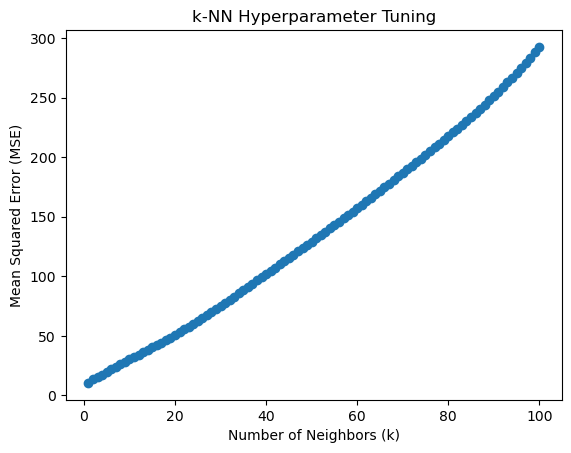

In [22]:
# Plot results
import matplotlib.pyplot as plt

k_values, mse_scores = zip(*scores)
plt.plot(k_values, mse_scores, marker='o', linestyle='-')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("k-NN Hyperparameter Tuning")
plt.show()

There are possible signs of overfitting since the best n_neighbor is 1, and the MSE scores are so accurate.

In [23]:
# Fit k-NN model with 7 features
knn = NearestNeighbors(n_neighbors=best_k, metric='euclidean')
knn.fit(df_users_filtered)

NearestNeighbors(metric='euclidean', n_neighbors=1)

We can now create a playlist based on the user's overall tracks. 

In [24]:
def recommend_songs(df, genre, n=30, random_state=42):
    """
    Generate a personalized playlist of `n` songs from a specific genre based on the user's preferences.

    Args:
        df: The user's listening history with audio features.
        genre: The genre of songs to recommend.
        n: The number of songs to recommend (default is 5).
        random_state: Seed for reproducibility (default is 42).

    Returns:
        random_recommendations: A DataFrame containing the recommended songs.
    """
    # Filter the Spotify dataset to include only songs from the specified genre
    genre_tracks = df_spotify_tracks[df_spotify_tracks['track_genre'].str.lower() == genre.lower()]

    # Check if there are enough songs in the specified genre
    if len(genre_tracks) < n:
        raise ValueError(f"Not enough songs in the '{genre}' genre. Only {len(genre_tracks)} songs available.")

    # Select relevant features for the KNN model
    features = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
                'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

    # Prepare the feature matrix for the user's listening history
    X_user = user_df[features]

    # Train the KNN model on the user's data
    # Standardize the features
    scaler = StandardScaler()
    X_user_scaled = scaler.fit_transform(X_user)

    # Ensure `n` does not exceed the number of available songs in the dataset
    max_neighbors = min(n, len(X_user_scaled))

    # Train the KNN model on the user's features
    knn = NearestNeighbors(n_neighbors=max_neighbors, metric='euclidean')  # Use Euclidean distance
    knn.fit(X_user_scaled)

    # Prepare the feature matrix for the genre-specific songs
    X_genre = genre_tracks[features]
    X_genre_scaled = scaler.transform(X_genre)

    # Find the nearest neighbors (most similar songs) in the genre-specific dataset
    distances, indices = knn.kneighbors(X_genre_scaled)

    # Flatten the indices array to get a list of all recommended song indices
    recommended_song_indices = indices.flatten()

    # Ensure indices are within the valid range of the genre_tracks DataFrame
    valid_indices = [idx for idx in recommended_song_indices if idx < len(genre_tracks)]

    if not valid_indices:
        raise ValueError("No valid recommendations found. Please check the input data.")

    # Get the recommended songs
    recommended_songs = genre_tracks.iloc[valid_indices].drop_duplicates(subset=['track_id']).head(n)

    # Randomly select `n` songs from the recommendations
    random_recommendations = recommended_songs.sample(n=n, random_state=random_state)

    # Display the recommended songs
    return random_recommendations

In [25]:

recommendations = recommend_songs(user_df, genre='electro', n=15)
recommendations

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,track_genre_encoded
25500,1iQDltZqI7BXnHrFy4Qo1k,SHAED;ZAYN,Trampoline (with ZAYN),Trampoline (with ZAYN),69,184280,0,0.619,0.459,7,...,0,0.0334,0.56000,0.000000,0.1370,0.498,126.803,4,electro,31
25719,3QAE1arPJAMVKt3NUqjikE,Juan Magán;Paulina Rubio;DCS,Queda poco para la PAES 2.0,Vuelve,0,213240,0,0.661,0.677,5,...,1,0.0383,0.62800,0.000000,0.0793,0.959,174.068,4,electro,31
25797,02xRKYZ1jY4B6utPa59qSf,Nessa Barrett,tired of california,tired of california,70,190800,0,0.712,0.731,6,...,0,0.0402,0.22800,0.000000,0.3720,0.638,92.014,4,electro,31
25491,4uDhts78RdwIDjEqPrYVKp,Alan Walker;Imanbek,Sweet Dreams,Sweet Dreams,75,138819,0,0.766,0.817,7,...,1,0.0350,0.02390,0.000002,0.1590,0.430,125.033,4,electro,31
25573,3E1WGK710MCDfi8inR9IcH,Jeremy Zucker,Die For You,Cry with you,0,217044,1,0.510,0.307,2,...,1,0.1010,0.32100,0.000002,0.1740,0.356,159.794,3,electro,31
25759,779UN3kabApm2zfqX549vf,Sasha Alex Sloan;Sam Hunt,when was it over? (feat. Sam Hunt),when was it over? (feat. Sam Hunt),67,218093,0,0.626,0.453,7,...,1,0.0306,0.81600,0.000002,0.0904,0.494,129.958,4,electro,31
25499,4pTkDIlpFNoeWbahu8pVXW,Izzamuzzic;Julien Marchal,Shootout,Shootout,78,295308,0,0.663,0.578,2,...,1,0.0687,0.31200,0.906000,0.1090,0.553,86.986,4,electro,31
25665,5QMLTolS9JqMTqouRtbSWT,Cali Y El Dandee;Danna Paola,Regageton Para Niños,Nada,1,174026,0,0.684,0.808,0,...,1,0.0610,0.05180,0.000010,0.0858,0.712,173.905,4,electro,31
25624,4vsAUbPb6q9FpC4AGBFdVh,Loote,lost,tomorrow tonight,65,202600,0,0.320,0.500,3,...,1,0.0994,0.13400,0.000000,0.1080,0.142,91.361,4,electro,31
25602,2cGxRwrMyEAp8dEbuZaVv6,Daft Punk;Julian Casablancas,Random Access Memories,Instant Crush (feat. Julian Casablancas),76,337560,0,0.775,0.585,10,...,0,0.0271,0.04220,0.619000,0.0770,0.518,109.942,4,electro,31


In [26]:
from music_rec import recommend_songs
recommend_songs(user_df, df_spotify_tracks, genre = 'electro')

,artists,track_name,track_genre
25696,Ellise,911,electro
25606,Alessia Cara,Sweet Dream,electro
25635,Otnicka,Babel,electro
25636,K.Flay,High Enough,electro
25759,Sasha Alex Sloan;Sam Hunt,when was it over? (feat. Sam Hunt),electro
25500,SHAED;ZAYN,Trampoline (with ZAYN),electro
25686,Midival Punditz;Karsh Kale;Raghu Dixit,Train Song,electro
25617,Alan Walker;K-391;Sofia Carson;CORSAK,Different World (feat. CORSAK),electro
25704,Calvin Harris;Justin Timberlake;Halsey;Pharrel...,"Stay With Me (with Justin Timberlake, Halsey, ...",electro
25797,Nessa Barrett,tired of california,electro


In [ ]:
from sklearn.preprocessing import LabelEncoder
max_neighbors = 5
X_genre_scaled = 5
X_spotify_genre_scaled = 5
recommended_song_indices = 5
label_encoder = LabelEncoder()
recommended_songs_by_genre = 5

def playlist_song_recs(users_playlists, spotify_tracks, playlist, n=5):
    """
    Function to test reccomendation system by inputing user playlist, and recommending 5 songs.
    Args:
        users_playlists: Df that contains the users tracks and their associated playlists (no song metrics)
        spotify tracks: Df that contains all songs in Kaggle dataset wth song metrics
        playlist: User's selected playlist to get recommended songs for
        n: Number of songs to get recommended
    Returns:
        random_recommendations: Df that contains 5 randomly selected songs from list of song recommendations
    """
    # Identify the requested playlist
    requested_playlist_tracks = users_playlists[users_playlists['name'].str.lower() == playlist.lower()]['track_id'].tolist()
    # Extract features for the requested playlist
    requested_playlist_features = spotify_tracks[spotify_tracks['track_id'].isin(requested_playlist_tracks)]
    ...
    # Filter the Spotify dataset to include only songs from the top genres
    main_genres = requested_playlist_features['track_genre'].value_counts()
    filtered_spotify_tracks = spotify_tracks[spotify_tracks['track_genre'].isin(main_genres)]
    ...
    for genre in main_genres:
        # Filter the requested playlist features for the current genre
        genre_features = requested_playlist_features[requested_playlist_features['track_genre'].str.lower() == genre.lower()]   
        ...   
        # Train the KNN model for the current genre
        knn = NearestNeighbors(n_neighbors=max_neighbors, metric='euclidean')  # Use Euclidean distance
        knn.fit(X_genre_scaled)    
        # Filter the Spotify dataset for the current genre
        genre_spotify_tracks = filtered_spotify_tracks[filtered_spotify_tracks['track_genre'].str.lower() == genre.lower()]   
        ...
        # Find the nearest neighbors (most similar songs) in the filtered Spotify dataset
        distances, indices = knn.kneighbors(X_spotify_genre_scaled)
        ...   
        # Get the recommended songs for the current genre
        genre_recommendations = genre_spotify_tracks.iloc[recommended_song_indices].drop_duplicates(subset=['track_id']).head(5)  
        # Add the recommendations to the list
        recommended_songs_by_genre.append(genre_recommendations)
    # Combine the recommendations
    balanced_recommendations = pd.concat(recommended_songs_by_genre)  # Ensure we have 5 songs in total
    ...  
    # Randomly select 5 songs from the combined recommendations
    random_recommendations = balanced_recommendations.sample(n=max_neighbors, random_state=42)  # Use random_state for reproducibility
    return random_recommendations

In [ ]:
X_user_scaled = 5
valid_indices = 5

def recommend_songs(user_songs, spotify_tracks, genre=None, n=30, random_state=42):
    """
    Generate a personalized playlist of `n` songs from a specific genre based on the user's preferences.

    Args:
        df: The user's listening history with audio features.
        genre: The genre of songs to recommend.
        n: The number of songs to recommend (default is 5).
        random_state: Seed for reproducibility (default is 42).
    Returns:
        random_recommendations: A DataFrame containing the recommended songs.
    """
    # Filter the Spotify dataset to include only songs from the specified genre
    genre_tracks = spotify_tracks[spotify_tracks['track_genre'].str.lower() == genre.lower()]
    ...
    # Train the KNN model on the user's features
    knn = NearestNeighbors(n_neighbors=max_neighbors, metric='euclidean')  # Use Euclidean distance
    knn.fit(X_user_scaled)
    ...
    # Find the nearest neighbors (most similar songs) in the genre-specific dataset
    distances, indices = knn.kneighbors(X_genre_scaled)
    ...
    # Get the recommended songs
    recommended_songs = genre_tracks.iloc[valid_indices].drop_duplicates(subset=['track_name', 'artists']).head(n)
    # Randomly select `n` songs from the recommendations
    random_recommendations = recommended_songs.sample(n=n, random_state=random_state)
    random_recommendations = random_recommendations[['artists', 'track_name', 'track_genre']]
    # Display the recommended songs
    return random_recommendations